In [2]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

In [3]:
mat = loadmat('./data/gait.mat')

for k, v in mat.items():
    print(k, getattr(v, 'shape', None), getattr(v, 'dtype', None))
    
cont = mat['cont']
park = mat['park']

__header__ None None
__version__ None None
__globals__ None None
cont (222, 2) float64
park (222, 2) float64


Text(0.5, 1.0, '1 axis')

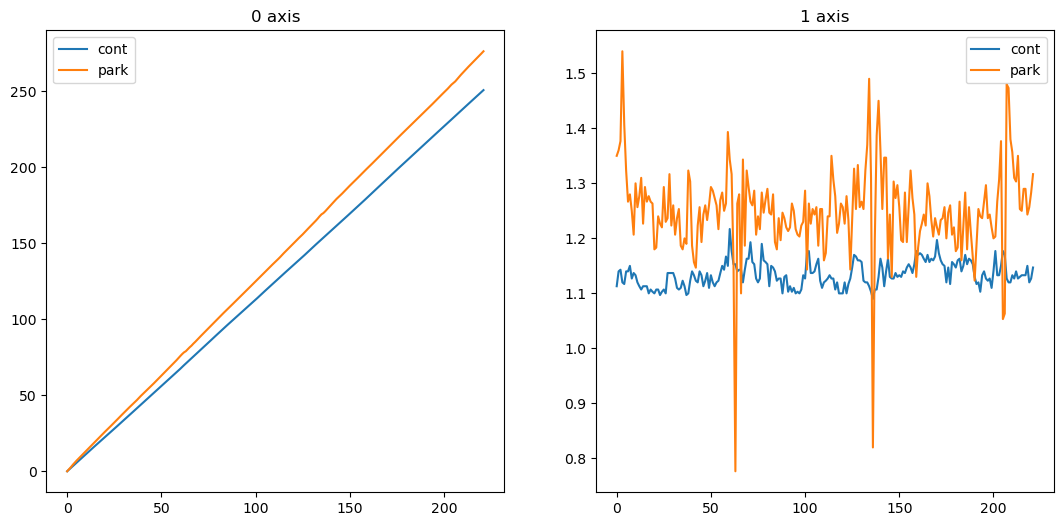

In [4]:
plt.figure(figsize=(13, 6))
plt.subplot(121)
plt.plot(cont[:, 0], label='cont')
plt.plot(park[:, 0], label='park')
plt.legend()
plt.title("0 axis")

plt.subplot(122)
plt.plot(cont[:, 1], label='cont')
plt.plot(park[:, 1], label='park')
plt.legend()
plt.title("1 axis")

F (2, 112), N: 222
park 1.01, cont 0.25


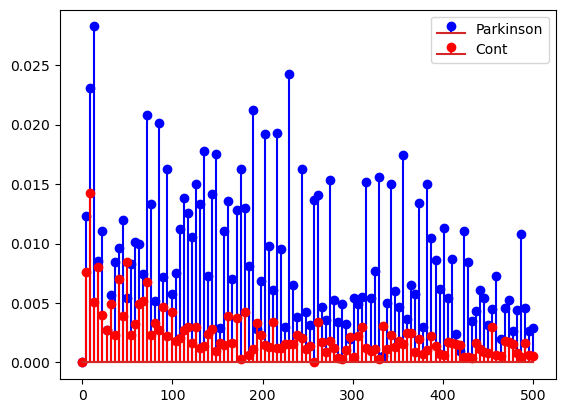

In [5]:
fs = 1000
N = cont.shape[0] # T

data = np.stack([park[:, 1], cont[:, 1]], axis=0) # 2 x T
data_demeaned = data - data.mean(axis=1, keepdims=True)

F = np.fft.rfft(data_demeaned, axis=1)
print(f"F {F.shape}, N: {N}")

F *= 2/N
F[:, 0] /= 2
hz = np.fft.rfftfreq(N, 1/fs)

plt.stem(hz, np.abs(F[0, :]), 'b', label='Parkinson')
plt.stem(hz, np.abs(F[1, :]), 'r', label='Cont')
plt.legend()
# plt.xlim(-0.1)

print(f'park {np.sum(np.abs(F[0, :])):.2f}, cont {np.sum(np.abs(F[1, :])):.2f}')

# DATA IS IRREGULAR, FOURIER ASSUMPTION BREAKS

[1.114 1.14  1.143 1.12  1.117 1.14  1.14  1.15  1.126 1.137]
[1.113 1.14  1.143 1.12  1.117 1.14  1.14  1.15  1.127 1.137]


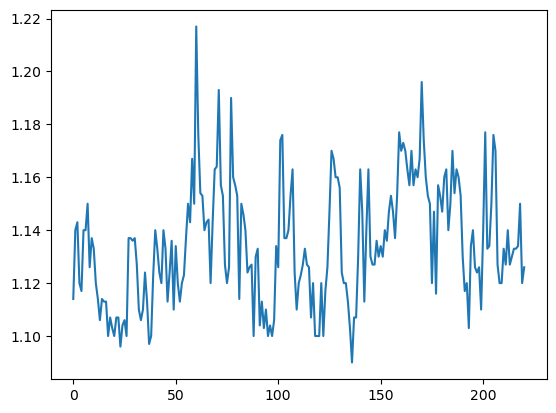

In [6]:
dt = np.diff(cont[:, 0])
plt.plot(dt)

dt.min(), dt.max()
print(np.diff(cont[:, 0])[:10])  # gaps between timestamps
print(cont[:, 1][:10])           # stride intervals

# First column is the timestamp of footprint (containing varying stride interval)

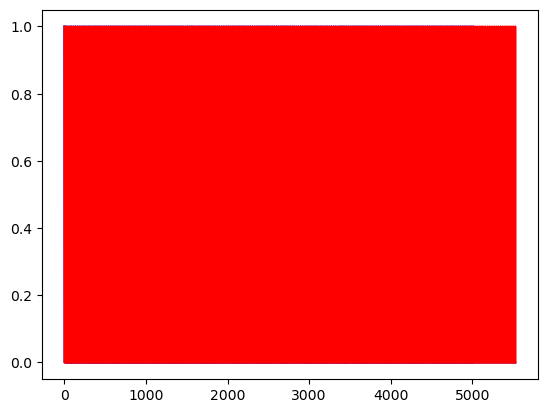

In [38]:
# now we just need to discritize it
# First get dt and N for creating a fine grid
cont_timestamp = cont[:, 0]
park_timestamp = park[:, 0]

# dt = np.min(np.diff(cont_timestamp)) * 1/10
dt = 0.05
N = int(np.floor(np.max(park_timestamp) / dt)) + 2 # floor good here?

# Now fill the new regular grid
cont_grid = np.zeros(N)
cont_footstep_indices = np.round(cont_timestamp / dt).astype(np.int64) # round or floor good here?
cont_grid[cont_footstep_indices] = 1

park_grid = np.zeros(N)
park_footstep_indices = np.round(park_timestamp / dt).astype(np.int64) # round or floor good here?
park_grid[park_footstep_indices] = 1

plt.plot(cont_grid, 'b', label='cont')
plt.plot(park_grid, 'r', label='park')

20.0 0.05


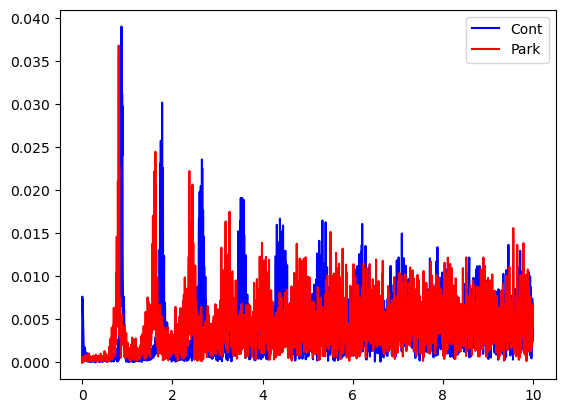

In [39]:
# now freq analyis for our regular signal!
fs = 1/dt
print(fs, dt) # idk i feel like the way i caluclated fs is just wrong..

cont_fft = np.fft.rfft(cont_grid - np.mean(cont_grid))
park_fft = np.fft.rfft(park_grid - np.mean(park_grid))

cont_fft *= 2/N
cont_fft[0] /= 2

park_fft *= 2/N
park_fft[0] /= 2

cont_hz = np.fft.rfftfreq(N, 1/fs)
park_hz = np.fft.rfftfreq(N, 1/fs)

plt.plot(cont_hz, np.abs(cont_fft), 'b', label='Cont')
plt.plot(park_hz, np.abs(park_fft), 'r', label='Park')
plt.legend()

In [ ]:
peak_idx = np.argmax(np.abs(cont_fft[1:]))  # skip DC
print("main stepping frequency:", cont_hz[1:][peak_idx], "Hz")
print("steps per second:", cont_hz[1:][peak_idx])
print("seconds per step:", 1/cont_hz[1:][peak_idx])

main stepping frequency: 0.0036119338293722344 Hz
steps per second: 0.0036119338293722344
seconds per step: 276.86000000000087
